In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [35]:
output_folder=("../PhysiCell/results/custom_stochastic_cell_cycle/cell_volumes.csv")
pc_df = pd.read_csv(output_folder,float_precision='round_trip',usecols=['id',"dt","current_phase"]).sort_values(by=['dt']).reset_index(drop=True)
pc_df

,id,current_phase,dt
0,0.0,4.0,0.0
1,0.0,4.0,30.0
2,0.0,4.0,60.0
3,0.0,4.0,90.0
4,0.0,10.0,120.0
...,...,...,...
195,0.0,4.0,2880.0
196,2.0,4.0,2880.0
197,3.0,10.0,2880.0
198,4.0,4.0,2880.0


In [36]:
df_s = pc_df[pc_df['current_phase']==4.0]
df_s

,id,current_phase,dt
0,0.0,4.0,0.0
1,0.0,4.0,30.0
2,0.0,4.0,60.0
3,0.0,4.0,90.0
31,2.0,4.0,900.0
...,...,...,...
194,4.0,4.0,2850.0
195,0.0,4.0,2880.0
196,2.0,4.0,2880.0
198,4.0,4.0,2880.0


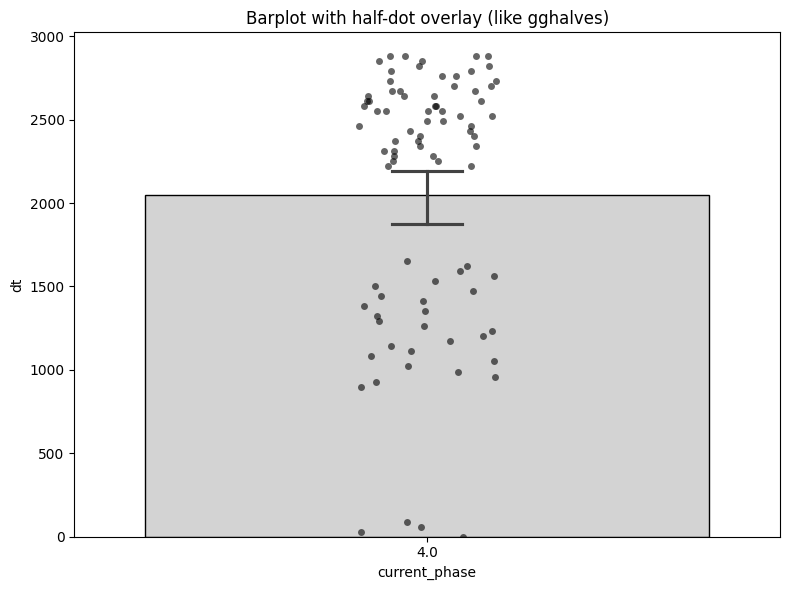

In [37]:
plt.figure(figsize=(8, 6))

# Barplot (showing mean and CI)
sns.barplot(x='current_phase', y='dt', data=df_s, capsize=0.1, color='lightgray', edgecolor='black')

# # Overlay points (jittered to one side to mimic gghalves)
sns.stripplot(x='current_phase', y='dt', data=df_s, 
              dodge=True, jitter=True, color='black', size=5, alpha=0.6)

plt.title("Barplot with half-dot overlay (like gghalves)")
plt.tight_layout()
plt.show()

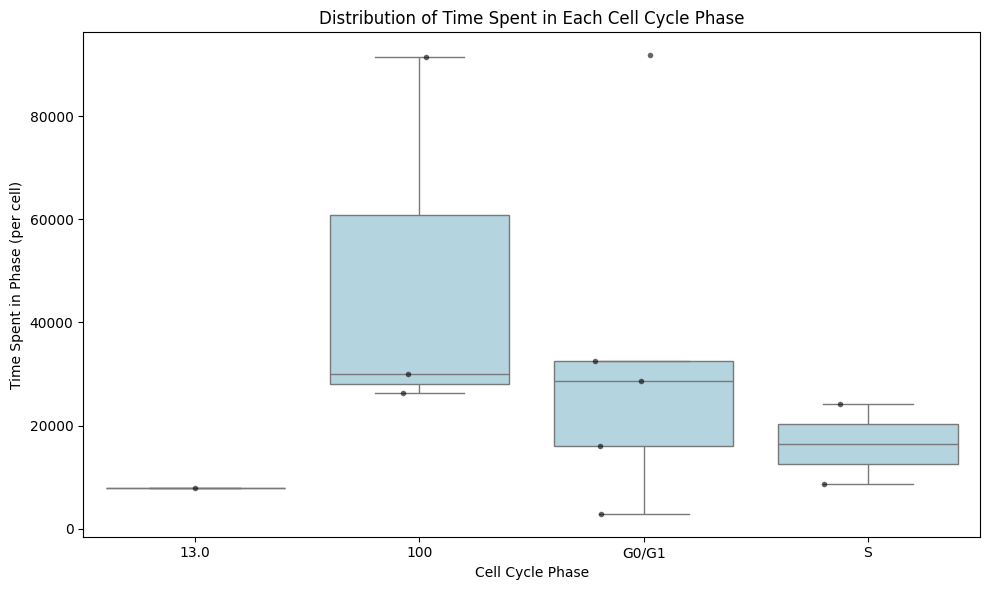

In [38]:
# Sum time spent by each cell in each phase
pc_df.replace({4.0: "G0/G1", 10.0: 100,12.0: "S", 14.0: "G2", 16.0: "M"}, inplace=True)

phase_times = pc_df.groupby(['id', 'current_phase'])['dt'].sum().reset_index(name='time_in_phase')
plt.figure(figsize=(10, 6))

# Boxplot of time spent per phase
sns.boxplot(data=phase_times, x='current_phase', y='time_in_phase', 
            color='lightblue', showfliers=False)

# Overlay points (jittered)
sns.stripplot(data=phase_times, x='current_phase', y='time_in_phase', 
              color='black', size=4, jitter=0.25, alpha=0.6)

plt.xlabel("Cell Cycle Phase")
plt.ylabel("Time Spent in Phase (per cell)")
plt.title("Distribution of Time Spent in Each Cell Cycle Phase")
plt.tight_layout()
# plt.show()

In [39]:
output_folder=("../Chaste/unit_test_cellcycle/results/cellcycle_fixed.dat")
ch_df = pd.DataFrame(columns=["dt","id","x","y","z","g1_duration","s_duration","g2_duration","m_duration","current_phase","target_area","volume"])
with open(output_folder, "r") as f:
    for line in f.read().splitlines():
        data = line.split()
        data = [float(x) if x.replace('.', '', 1).isdigit() else x for x in data]
        dt = data[0]
        for i in range(0,len(data)//11):
            row = {'dt': dt, 'id': data[1+11*i], 'x': data[2+11*i], 'y': data[3+11*i], 'z': data[4+11*i], 'g1_duration': data[5+11*i], 's_duration': data[6+11*i], 'g2_duration': data[7+11*i], 'm_duration': data[8+11*i], 'current_phase': data[9+11*i], 'target_area': data[10+11*i], 'volume': data[11+11*i]}
            row = pd.Series(row)
            df2 = pd.DataFrame(row).transpose()

            ch_df =pd.concat([ch_df,df2],ignore_index=True)
ch_df

,dt,id,x,y,z,g1_duration,s_duration,g2_duration,m_duration,current_phase,target_area,volume
0,0.0,0.0,0.0,0.0,0.1,7.0,6.0,3.0,2.0,G1,0.523599,0.523599
1,0.1,0.0,0.0,0.0,3.0,7.0,6.0,3.0,2.0,G1,0.523599,0.523599
2,0.2,0.0,0.0,0.0,3.0,7.0,6.0,3.0,2.0,G1,0.523599,0.523599
3,0.3,0.0,0.0,0.0,3.0,7.0,6.0,3.0,2.0,G1,0.523599,0.523599
4,0.4,0.0,0.0,0.0,3.0,7.0,6.0,3.0,2.0,G1,0.523599,0.523599
...,...,...,...,...,...,...,...,...,...,...,...,...
1016,47.9,3.0,-0.963926,-0.588464,2.77931,7.0,6.0,3.0,2.0,S,0.871807,0.870852
1017,48.0,0.0,0.826793,0.787988,2.77407,7.0,6.0,3.0,2.0,S,0.877028,0.876112
1018,48.0,1.0,-0.29871,0.37595,2.96132,7.0,6.0,3.0,2.0,S,0.877028,0.876041
1019,48.0,2.0,0.620875,-0.372871,2.91127,7.0,6.0,3.0,2.0,S,0.877028,0.876065


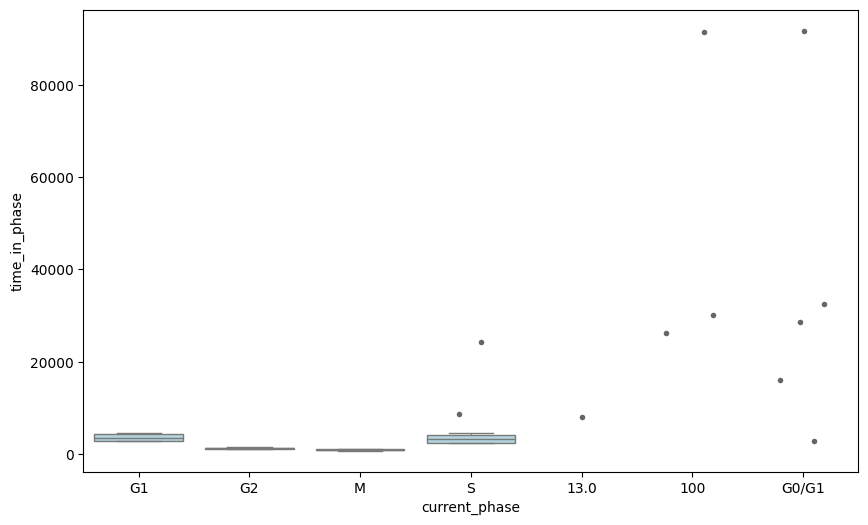

In [40]:
# Sum time spent by each cell in each phase
phase_times_ch = ch_df.groupby(['id', 'current_phase'])['dt'].sum().reset_index(name='time_in_phase')

plt.figure(figsize=(10, 6))

# Boxplot of time spent per phase
sns.boxplot(data=phase_times_ch, x='current_phase', y='time_in_phase', 
            color='lightblue', showfliers=False)

# Overlay points (jittered)
sns.stripplot(data=phase_times, x='current_phase', y='time_in_phase', 
              color='black', size=4, jitter=0.25, alpha=0.6)
plt.show()